## 1. Welcome!
<p><img src="https://assets.datacamp.com/production/project_1170/img/office_cast.jpeg" alt="Markdown">.</p>
<p><strong>The Office!</strong> What started as a British mockumentary series about office culture in 2001 has since spawned ten other variants across the world, including an Israeli version (2010-13), a Hindi version (2019-), and even a French Canadian variant (2006-2007). Of all these iterations (including the original), the American series has been the longest-running, spanning 201 episodes over nine seasons.</p>
<p>In this notebook, we will take a look at a dataset of The Office episodes, and try to understand how the popularity and quality of the series varied over time. To do so, we will use the following dataset: <code>datasets/office_episodes.csv</code>, which was downloaded from Kaggle <a href="https://www.kaggle.com/nehaprabhavalkar/the-office-dataset">here</a>.</p>
<p>This dataset contains information on a variety of characteristics of each episode. In detail, these are:
<br></p>
<div style="background-color: #efebe4; color: #05192d; text-align:left; vertical-align: middle; padding: 15px 25px 15px 25px; line-height: 1.6;">
    <div style="font-size:20px"><b>datasets/office_episodes.csv</b></div>
<ul>
    <li><b>episode_number:</b> Canonical episode number.</li>
    <li><b>season:</b> Season in which the episode appeared.</li>
    <li><b>episode_title:</b> Title of the episode.</li>
    <li><b>description:</b> Description of the episode.</li>
    <li><b>ratings:</b> Average IMDB rating.</li>
    <li><b>votes:</b> Number of votes.</li>
    <li><b>viewership_mil:</b> Number of US viewers in millions.</li>
    <li><b>duration:</b> Duration in number of minutes.</li>
    <li><b>release_date:</b> Airdate.</li>
    <li><b>guest_stars:</b> Guest stars in the episode (if any).</li>
    <li><b>director:</b> Director of the episode.</li>
    <li><b>writers:</b> Writers of the episode.</li>
    <li><b>has_guests:</b> True/False column for whether the episode contained guest stars.</li>
    <li><b>scaled_ratings:</b> The ratings scaled from 0 (worst-reviewed) to 1 (best-reviewed).</li>
</ul>
    </div>

In [119]:
# Use this cell to begin your analysis, and add as many as you would like!
import pandas as pd
import matplotlib.pyplot as plt

office_df = pd.read_csv('datasets/office_episodes.csv')

In [120]:
"""
A color scheme reflecting the scaled ratings (not the regular ratings) of each episode, such that:
Ratings < 0.25 are colored "red"
Ratings >= 0.25 and < 0.50 are colored "orange"
Ratings >= 0.50 and < 0.75 are colored "lightgreen"
Ratings >= 0.75 are colored "darkgreen"
"""

colors = []

for i, row in office_df.iterrows():
    if row['scaled_ratings'] < 0.25:
        colors.append('red')
    elif (row['scaled_ratings'] >= 0.25) & (row['scaled_ratings'] < 0.50):
        colors.append('orange')
    elif (row['scaled_ratings'] >= 0.50) & (row['scaled_ratings'] < 0.75):
        colors.append('lightgreen')
    else:
        colors.append('darkgreen')
                       
print(colors)

['orange', 'lightgreen', 'orange', 'orange', 'lightgreen', 'orange', 'lightgreen', 'orange', 'lightgreen', 'lightgreen', 'orange', 'orange', 'lightgreen', 'orange', 'lightgreen', 'lightgreen', 'lightgreen', 'darkgreen', 'lightgreen', 'orange', 'orange', 'lightgreen', 'lightgreen', 'lightgreen', 'orange', 'lightgreen', 'lightgreen', 'darkgreen', 'darkgreen', 'orange', 'lightgreen', 'orange', 'orange', 'orange', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'orange', 'orange', 'lightgreen', 'lightgreen', 'darkgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'darkgreen', 'darkgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'orange', 'lightgreen', 'darkgreen', 'orange', 'lightgreen', 'lightgreen', 'orange', 'darkgreen', 'lightgreen', 'lightgreen', 'orange', 'orange', 'orange', 'lightgreen', 'orange', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen', 'orange', 'darkgreen', 'orange', 'orang

In [121]:
"""
A sizing system, such that episodes with guest appearances have a marker size of 250 and episodes without are sized 25
"""

sizes = []

for i, row in office_df.iterrows():
    if row['has_guests'] == True:
        sizes.append(250)
    elif row['has_guests'] == False:
        sizes.append(25)

print(sizes)

[25, 25, 25, 25, 25, 250, 25, 25, 250, 250, 25, 25, 250, 25, 250, 25, 250, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 250, 250, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 25, 25, 25, 250, 250, 25, 25, 25, 250, 25, 25, 25, 25, 25, 25, 25, 250, 25, 25, 250, 25, 250]


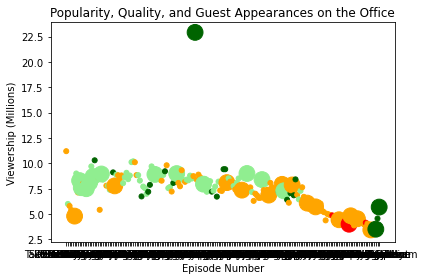

In [122]:
"""
Each episode's episode number plotted along the x-axis
Each episode's viewership (in millions) plotted along the y-axis
"""
fig = plt.figure()

plt.scatter(office_df['episode_title'], office_df['viewership_mil'], s = sizes, c = colors)

"""
A title, reading "Popularity, Quality, and Guest Appearances on the Office"
"""
plt.title("Popularity, Quality, and Guest Appearances on the Office")

"""
An x-axis label reading "Episode Number"
"""
plt.xlabel('Episode Number')


"""
A y-axis label reading "Viewership (Millions)"
"""
plt.ylabel('Viewership (Millions)')

plt.show()

In [126]:
top_star = office_df[office_df['viewership_mil'] > 20 ]['guest_stars']
print(top_star)

77    Cloris Leachman, Jack Black, Jessica Alba
Name: guest_stars, dtype: object
